In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import logging
logger = logging.getLogger('cmdstanpy')
logger.addHandler(logging.NullHandler())
logger.propagate = False
logger.setLevel(logging.ERROR)

# ==========================================
# STEP 1: LOAD AND CLEAN THE DATASET
# ==========================================
df = pd.read_csv('https://www.dropbox.com/scl/fi/xykgsm48xmslcrrju38jr/household_power_consumption.txt?rlkey=3kw97zxuidsesk1nzilcbm7dl&st=fokwfi22&dl=1', sep=';', low_memory=False, na_values=['?'])

# Combine Date and Time columns into a single string column
df['Datetime_String'] = df['Date'] + ' ' + df['Time']

# Convert that string column into an actual Datetime format pandas can read
df['Datetime'] = pd.to_datetime(df['Datetime_String'], dayfirst=True)

# Set the datetime as our index so it becomes a true time series
df.set_index('Datetime', inplace=True)

# Remove the old, unused columns to keep it simple
df = df.drop(columns=['Date', 'Time', 'Datetime_String'])

# Look for any null values and fill them using Forward Fill (fills gaps with the previous minute's value)
df = df.ffill()


In [3]:
# ==========================================
# STEP 2: RESAMPLE DATA TO HOURLY (REDUCE TO ~35,000 ROWS)
# ==========================================

# Take the hourly average. This shrinks our rows from 2 million down to around 34,500!
df_hourly = df.resample('h').mean()

# We only need the main target column: 'Global_active_power'
df_model = df_hourly[['Global_active_power']].copy()

# Remove any extra null rows created at the very edges during resampling
df_model = df_model.dropna()
print(f"Dataset successfully reduced! New shape: {df_model.shape}")

# ==========================================
# STEP 3: FEATURE ENGINEERING (TIME-BASED FEATURES)
# ==========================================
# Extract simple time components from the index
df_model['Hour'] = df_model.index.hour
df_model['DayOfWeek'] = df_model.index.dayofweek

# Create a weekend flag: 1 if Saturday(5) or Sunday(6), otherwise 0
df_model['IsWeekend'] = 0
df_model.loc[df_model['DayOfWeek'] >= 5, 'IsWeekend'] = 1

# Create a Lag feature (the power usage from exactly 1 hour ago) to help XGBoost see past patterns
df_model['Lag_1'] = df_model['Global_active_power'].shift(1)

# Drop the first row because its Lag_1 feature will be NaN
df_model = df_model.dropna()

Dataset successfully reduced! New shape: (34589, 1)


In [4]:
# ==========================================
# STEP 4: TRAIN / TEST SPLIT (LAST 7 DAYS FOR TESTING)
# ==========================================
print("--- Step 4: Splitting Data ---")

# Since it's hourly data, 7 days * 24 hours = 168 rows
test_size = 168

train_data = df_model.iloc[:-test_size]
test_data = df_model.iloc[-test_size:]

print(f"Training rows: {len(train_data)}, Testing rows: {len(test_data)}")

# ==========================================
# STEP 5: MODEL TRAINING & FORECASTING
# ==========================================
print("--- Step 5: Training Models ---")

# Create a storage dataframe to easily compare our final results
results = pd.DataFrame(index=test_data.index)
results['Actual'] = test_data['Global_active_power']

# ----- MODEL A: ARIMA -----
print("Training ARIMA...")
# We use order=(1,1,1) which means Auto-Regressive(1), Difference(1), Moving Average(1)
arima_model = ARIMA(train_data['Global_active_power'], order=(1, 1, 1))
arima_fitted = arima_model.fit()
# Forecast 168 hours into the future
results['ARIMA_Forecast'] = arima_fitted.forecast(steps=test_size)


# ----- MODEL B: PROPHET -----
print("Training Prophet...")
# Prophet requires a dataframe with specifically named columns: 'ds' for time and 'y' for values
prophet_train = pd.DataFrame()
prophet_train['ds'] = train_data.index
prophet_train['y'] = train_data['Global_active_power'].values

prophet_model = Prophet()
prophet_model.fit(prophet_train)

# Create a future dataframe for the next 168 hours
future_dates = prophet_model.make_future_dataframe(periods=test_size, freq='h')
prophet_forecast = prophet_model.predict(future_dates)
# Extract just the prediction values for our test dates
results['Prophet_Forecast'] = prophet_forecast['yhat'].iloc[-test_size:].values


# ----- MODEL C: XGBOOST -----
print("Training XGBoost...")
# For Machine Learning, we separate our features (X) from our target variable (y)
X_train = train_data[['Hour', 'DayOfWeek', 'IsWeekend', 'Lag_1']]
y_train = train_data['Global_active_power']

X_test = test_data[['Hour', 'DayOfWeek', 'IsWeekend', 'Lag_1']]

xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

results['XGBoost_Forecast'] = xgb_model.predict(X_test)

--- Step 4: Splitting Data ---
Training rows: 34420, Testing rows: 168
--- Step 5: Training Models ---
Training ARIMA...
Training Prophet...
Training XGBoost...



--- Step 6: Calculating Performance Metrics ---

MODEL EVALUATION SUMMARY
ARIMA   -> MAE: 0.699 | RMSE: 0.859
Prophet -> MAE: 0.602 | RMSE: 0.756
XGBoost -> MAE: 0.360 | RMSE: 0.563
--- Step 7: Generating Visualization Plot ---


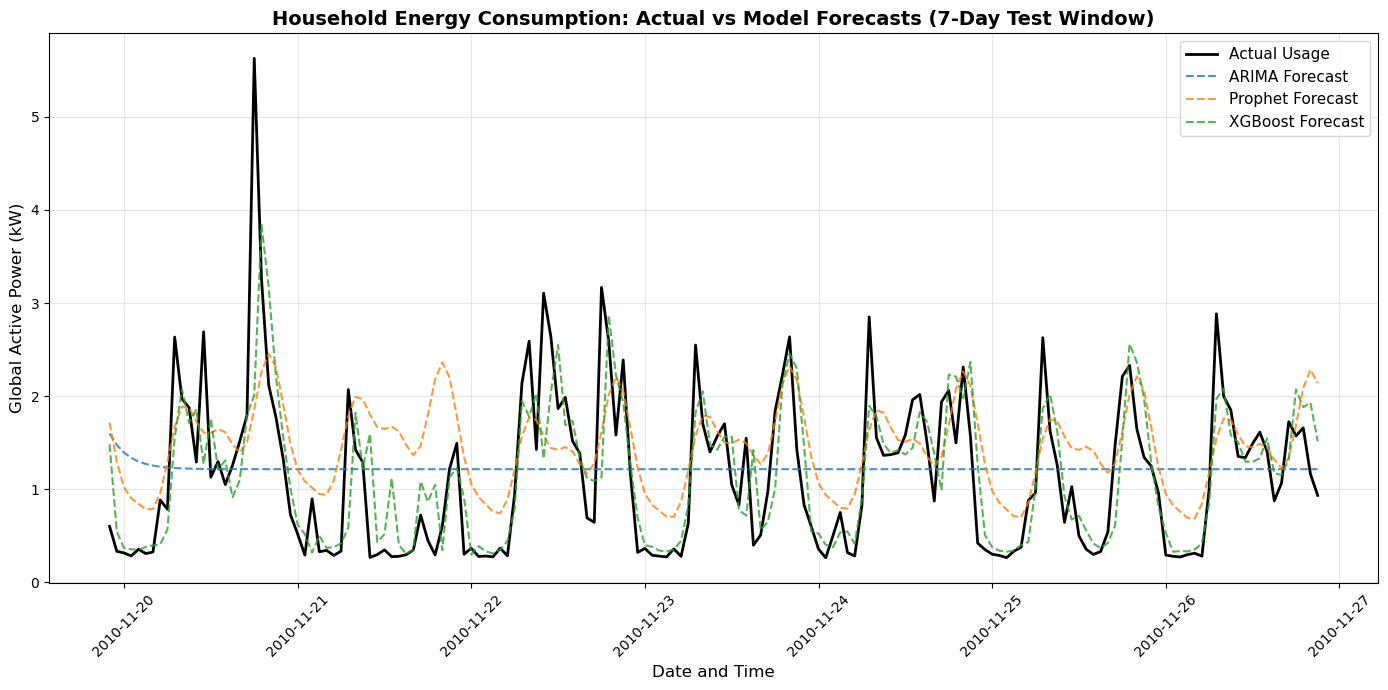

In [5]:
# ==========================================
# STEP 6: MODEL COMPARISON & EVALUATION
# ==========================================
print("\n--- Step 6: Calculating Performance Metrics ---")

# Calculate metrics for ARIMA
arima_mae = mean_absolute_error(results['Actual'], results['ARIMA_Forecast'])
arima_rmse = np.sqrt(mean_squared_error(results['Actual'], results['ARIMA_Forecast']))

# Calculate metrics for Prophet
prophet_mae = mean_absolute_error(results['Actual'], results['Prophet_Forecast'])
prophet_rmse = np.sqrt(mean_squared_error(results['Actual'], results['Prophet_Forecast']))

# Calculate metrics for XGBoost
xgb_mae = mean_absolute_error(results['Actual'], results['XGBoost_Forecast'])
xgb_rmse = np.sqrt(mean_squared_error(results['Actual'], results['XGBoost_Forecast']))

# Print a nice summary table in the console
print("\n=============================================")
print("MODEL EVALUATION SUMMARY")
print("=============================================")
print(f"ARIMA   -> MAE: {arima_mae:.3f} | RMSE: {arima_rmse:.3f}")
print(f"Prophet -> MAE: {prophet_mae:.3f} | RMSE: {prophet_rmse:.3f}")
print(f"XGBoost -> MAE: {xgb_mae:.3f} | RMSE: {xgb_rmse:.3f}")
print("=============================================")

# ==========================================
# STEP 7: VISUALIZATION
# ==========================================
print("--- Step 7: Generating Visualization Plot ---")

plt.figure(figsize=(14, 7))

# Plot actual vs forecasted lines
plt.plot(results.index, results['Actual'], label='Actual Usage', color='black', linewidth=2)
plt.plot(results.index, results['ARIMA_Forecast'], label='ARIMA Forecast', linestyle='--', alpha=0.8)
plt.plot(results.index, results['Prophet_Forecast'], label='Prophet Forecast', linestyle='--', alpha=0.8)
plt.plot(results.index, results['XGBoost_Forecast'], label='XGBoost Forecast', linestyle='--', alpha=0.8)

# Customize graph aesthetics
plt.title('Household Energy Consumption: Actual vs Model Forecasts (7-Day Test Window)', fontsize=14, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Rotate x-axis dates so they don't overlap
plt.xticks(rotation=45)
plt.tight_layout()

# Display the final plot
plt.show()